# Roslagsbanan vs Bus Reliability

## Setup and Data Scope

This first implementation block loads both rail lines and all bus lines in scope:

- Rail: `28`, `28S`
- Buses: `624`, `626`, `628`, `629`, `670`, `670X`, `676`, `676X`, `680`, `694`, `699`
- Context only: `14`


In [3]:
from pathlib import Path
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

DATA_DIR = Path("GTFS delay data")
RAIL_LINES = ["28", "28S"]
RAIL_LINE = RAIL_LINES[0]  # primary rail label kept for backward compatibility in later cells
BUS_LINES = ["624", "626", "628", "629", "670", "670X", "676", "676X", "680", "694", "699"]
CONTEXT_LINES = ["14"]
ALL_ANALYSIS_LINES = RAIL_LINES + BUS_LINES

print(f"GTFS folder exists: {DATA_DIR.exists()}")
print(f"Analysis lines ({len(ALL_ANALYSIS_LINES)}): {ALL_ANALYSIS_LINES}")

GTFS folder exists: True
Analysis lines (13): ['28', '28S', '624', '626', '628', '629', '670', '670X', '676', '676X', '680', '694', '699']


In [8]:
def load_line_file(line_id: str) -> pd.DataFrame:
    file_path = DATA_DIR / f"stop_times_{line_id}.csv"
    if not file_path.exists():
        raise FileNotFoundError(f"Missing file for line {line_id}: {file_path}")

    try:
        df = pd.read_csv(file_path)
    except pd.errors.EmptyDataError:
        print(f"Skipping empty file for line {line_id}: {file_path}")
        return pd.DataFrame()

    df["line"] = df["route_short_name"].astype(str)
    df["mode_group"] = np.where(df["line"].isin(RAIL_LINES), "rail", "bus")

    # Parse realtime observation timestamp from GTFS-RT snapshot timestamp
    df["observation_time"] = pd.to_datetime(df["timestamp"], errors="coerce")
    df["observation_date"] = df["observation_time"].dt.date
    df["hour"] = df["observation_time"].dt.hour
    
    # Extract day of week (0=Monday, 6=Sunday) and is_weekend flag
    df["day_of_week"] = df["observation_time"].dt.dayofweek
    df["is_weekend"] = df["day_of_week"].isin([5, 6])

    # Peak windows requested in project scope
    df["peak_window"] = np.select(
        [
            df["hour"].between(7, 8, inclusive="both"),
            df["hour"].between(16, 17, inclusive="both"),
        ],
        ["AM_peak_07_09", "PM_peak_16_18"],
        default="off_peak",
    )

    # Use departure delay as primary metric for reliability at stop level
    df["delay_sec"] = pd.to_numeric(df["departure_delay"], errors="coerce")
    df["on_time_2min"] = df["delay_sec"].between(-120, 120, inclusive="both")

    return df

frames = [load_line_file(line) for line in ALL_ANALYSIS_LINES]
gtfs = pd.concat(frames, ignore_index=True)

context_frames = [load_line_file(line) for line in CONTEXT_LINES if (DATA_DIR / f"stop_times_{line}.csv").exists()]
context_gtfs = pd.concat(context_frames, ignore_index=True) if context_frames else pd.DataFrame()

print(f"Rows (analysis scope): {len(gtfs):,}")
print(f"Rows (context only): {len(context_gtfs):,}")
print("Lines loaded:", sorted(gtfs['line'].unique().tolist()))

Rows (analysis scope): 194,458
Rows (context only): 116,989
Lines loaded: ['28', '28S', '624', '626', '628', '629', '670', '670X', '676', '676X', '680', '694', '699']


In [9]:
TARGET_STOP_NAMES = sorted([
    "Arninge station",
    "Arninge",
    "Roslags Näsby",
    "Roslags Näsby trafikplats",
    "Mörby",
    "Mörby centrum",
    "Mörby centrum/E18",
    "Danderyds sjukhus",
    "Universitetet",
    "Universitetet södra",
    "Albano",
    "Roslagstull",
    "Stockholms östra",
    "Tekniska högskolan",
])

# IMPORTANT: always start from freshly loaded gtfs to avoid using stale raw_gtfs from earlier runs
source_df = gtfs_corridor.copy() if "gtfs_corridor" in globals() and len(gtfs_corridor) else gtfs.copy()
site_scope_gtfs = source_df[source_df["stop_name"].isin(TARGET_STOP_NAMES)].copy()

print(f"Rows before site filter: {len(source_df):,}")
print(f"Rows after site filter: {len(site_scope_gtfs):,}")
removed_rows = len(source_df) - len(site_scope_gtfs)
removed_pct = (100 * removed_rows / len(source_df)) if len(source_df) else 0
print(f"Rows removed: {removed_rows:,} ({removed_pct:.1f}%)")
print("Selected stop names:")
for stop_name in TARGET_STOP_NAMES:
    print(f"  - {stop_name}")

# Update gtfs so the rest of the notebook uses the exact site list
gtfs = site_scope_gtfs

print(f"\nUnique stops in analysis: {gtfs['stop_name'].nunique()}")
print(f"Lines represented: {sorted(gtfs['line'].unique().tolist())}")

Rows before site filter: 194,458
Rows after site filter: 48,771
Rows removed: 145,687 (74.9%)
Selected stop names:
  - Albano
  - Arninge
  - Arninge station
  - Danderyds sjukhus
  - Mörby
  - Mörby centrum
  - Mörby centrum/E18
  - Roslags Näsby
  - Roslags Näsby trafikplats
  - Roslagstull
  - Stockholms östra
  - Tekniska högskolan
  - Universitetet
  - Universitetet södra

Unique stops in analysis: 14
Lines represented: ['28', '28S', '624', '626', '628', '629', '670', '670X', '676', '676X', '680', '694', '699']


In [10]:
raw_gtfs = gtfs.copy()

# Find shared dates separately for weekdays and weekends to include both
weekday_lines = raw_gtfs[~raw_gtfs["is_weekend"]].groupby("line")["observation_date"].apply(lambda s: set(s.dropna())).to_dict()
weekend_lines = raw_gtfs[raw_gtfs["is_weekend"]].groupby("line")["observation_date"].apply(lambda s: set(s.dropna())).to_dict()

# Get shared dates for each day type
shared_weekday_dates = sorted(set.intersection(*weekday_lines.values())) if weekday_lines else []
shared_weekend_dates = sorted(set.intersection(*weekend_lines.values())) if weekend_lines else []
shared_dates = sorted(shared_weekday_dates + shared_weekend_dates)

# Filter to shared dates
balanced_gtfs = raw_gtfs[raw_gtfs["observation_date"].isin(shared_dates)].copy()
gtfs = balanced_gtfs

shared_day_counts = gtfs.groupby("line")["observation_date"].nunique().reset_index(name="shared_days")
original_day_counts = raw_gtfs.groupby("line")["observation_date"].nunique().reset_index(name="original_days")
shared_day_summary = original_day_counts.merge(shared_day_counts, on="line", how="left")

print(f"Shared weekday dates: {shared_weekday_dates}")
print(f"Shared weekend dates: {shared_weekend_dates}")
print(f"Total shared dates used for main analysis: {len(shared_dates)} ({len(shared_weekday_dates)} weekdays, {len(shared_weekend_dates)} weekends)")
print(f"Rows before filter: {len(raw_gtfs):,}")
print(f"Rows after filter: {len(gtfs):,}")
display(shared_day_summary.sort_values("line"))

Shared weekday dates: [datetime.date(2026, 4, 16), datetime.date(2026, 4, 17), datetime.date(2026, 4, 20), datetime.date(2026, 4, 21), datetime.date(2026, 4, 22), datetime.date(2026, 4, 23), datetime.date(2026, 4, 27), datetime.date(2026, 4, 28), datetime.date(2026, 4, 29)]
Shared weekend dates: [datetime.date(2026, 4, 18), datetime.date(2026, 4, 19), datetime.date(2026, 4, 25), datetime.date(2026, 4, 26)]
Total shared dates used for main analysis: 13 (9 weekdays, 4 weekends)
Rows before filter: 48,771
Rows after filter: 40,069


,line,original_days,shared_days
0,28,18,13
1,28S,15,13
2,624,13,9
3,626,16,13
4,628,13,9
5,629,18,13
6,670,18,13
7,670X,13,9
8,676,18,13
9,676X,12,9


In [11]:
def reliability_summary(df: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    out = (
        df.dropna(subset=["delay_sec"])
        .groupby(group_cols, dropna=False)
        .agg(
            observations=("delay_sec", "size"),
            avg_delay_sec=("delay_sec", "mean"),
            median_delay_sec=("delay_sec", "median"),
            p90_delay_sec=("delay_sec", lambda s: s.quantile(0.90)),
            p95_delay_sec=("delay_sec", lambda s: s.quantile(0.95)),
            on_time_share_2min=("on_time_2min", "mean"),
        )
        .reset_index()
    )

    out["on_time_share_2min"] = (100 * out["on_time_share_2min"]).round(1)
    for c in ["avg_delay_sec", "median_delay_sec", "p90_delay_sec", "p95_delay_sec"]:
        out[c] = out[c].round(1)

    return out.sort_values(group_cols).reset_index(drop=True)

per_line_baseline = reliability_summary(gtfs, ["mode_group", "line"])
pooled_mode_baseline = reliability_summary(gtfs, ["mode_group"])

print("Per-line baseline reliability (all buses included):")
display(per_line_baseline)

print("\nPooled mode baseline (rail vs all buses):")
display(pooled_mode_baseline)

Per-line baseline reliability (all buses included):


,mode_group,line,observations,avg_delay_sec,median_delay_sec,p90_delay_sec,p95_delay_sec,on_time_share_2min
0,bus,624,942,34.9,39.0,172.8,232.8,68.7
1,bus,626,744,106.7,89.0,322.0,413.3,51.2
2,bus,628,1388,28.7,31.0,197.0,260.0,59.9
3,bus,629,2960,62.5,53.0,201.0,264.0,65.0
4,bus,670,11859,88.5,93.0,273.0,347.0,44.9
5,bus,670X,342,2.5,-43.0,201.1,280.1,56.4
6,bus,676,8455,42.2,34.0,189.0,253.0,66.6
7,bus,676X,434,31.5,25.5,194.7,254.1,61.3
8,bus,680,1525,100.3,99.0,303.0,384.6,47.1
9,bus,694,240,26.5,42.5,154.4,199.1,72.9



Pooled mode baseline (rail vs all buses):


,mode_group,observations,avg_delay_sec,median_delay_sec,p90_delay_sec,p95_delay_sec,on_time_share_2min
0,bus,29185,65.9,58.0,241.0,314.0,55.9
1,rail,10873,88.4,77.0,179.0,227.0,75.1


In [38]:
# Interpretation template: key observations
mode_comparison = pooled_mode_baseline.copy()
rail_delay = mode_comparison[mode_comparison["mode_group"] == "rail"]["avg_delay_sec"].values[0] if len(mode_comparison[mode_comparison["mode_group"] == "rail"]) > 0 else 0
bus_delay = mode_comparison[mode_comparison["mode_group"] == "bus"]["avg_delay_sec"].values[0] if len(mode_comparison[mode_comparison["mode_group"] == "bus"]) > 0 else 0
rail_ontime = mode_comparison[mode_comparison["mode_group"] == "rail"]["on_time_share_2min"].values[0] if len(mode_comparison[mode_comparison["mode_group"] == "rail"]) > 0 else 0
bus_ontime = mode_comparison[mode_comparison["mode_group"] == "bus"]["on_time_share_2min"].values[0] if len(mode_comparison[mode_comparison["mode_group"] == "bus"]) > 0 else 0

summary_text = f"""
from {len(shared_dates)} shared days: {shared_dates}):
===================================================================

1. AVERAGE DELAY:
   - Rail (line 28):     {rail_delay:.1f} sec (~{rail_delay/60:.1f} min)
   - Buses (all):        {bus_delay:.1f} sec (~{bus_delay/60:.1f} min)
   - Difference:         {abs(rail_delay - bus_delay):.1f} sec ({'+' if rail_delay > bus_delay else '-'} {'rail slower' if rail_delay > bus_delay else 'buses slower'})

2. ON-TIME SHARE (within ±2 min):
   - Rail (line 28):     {rail_ontime:.1f}%
   - Buses (all):        {bus_ontime:.1f}%
   - Gap:                {abs(rail_ontime - bus_ontime):.1f} percentage points"""


positive_delay = (
   gtfs.dropna(subset=["delay_sec"])
   .loc[lambda d: d["delay_sec"] > 0]
   .groupby("mode_group")["delay_sec"]
   .mean()
)

rail_pos_delay = positive_delay.get("rail", np.nan)
bus_pos_delay = positive_delay.get("bus", np.nan)

summary_text += f"""

3. AVERAGE POSITIVE DELAY (delay > 0 sec):
   - Rail (line 28):     {rail_pos_delay:.1f} sec (~{rail_pos_delay/60:.1f} min)
   - Buses (all):        {bus_pos_delay:.1f} sec (~{bus_pos_delay/60:.1f} min)
   - Gap:                {abs(rail_pos_delay - bus_pos_delay):.1f} sec
"""

print(summary_text)



from 13 shared days: [datetime.date(2026, 4, 16), datetime.date(2026, 4, 17), datetime.date(2026, 4, 18), datetime.date(2026, 4, 19), datetime.date(2026, 4, 20), datetime.date(2026, 4, 21), datetime.date(2026, 4, 22), datetime.date(2026, 4, 23), datetime.date(2026, 4, 25), datetime.date(2026, 4, 26), datetime.date(2026, 4, 27), datetime.date(2026, 4, 28), datetime.date(2026, 4, 29)]):

1. AVERAGE DELAY:
   - Rail (line 28):     88.4 sec (~1.5 min)
   - Buses (all):        65.9 sec (~1.1 min)
   - Difference:         22.5 sec (+ rail slower)

2. ON-TIME SHARE (within ±2 min):
   - Rail (line 28):     75.1%
   - Buses (all):        55.9%
   - Gap:                19.2 percentage points

3. AVERAGE POSITIVE DELAY (delay > 0 sec):
   - Rail (line 28):     96.5 sec (~1.6 min)
   - Buses (all):        135.4 sec (~2.3 min)
   - Gap:                39.0 sec



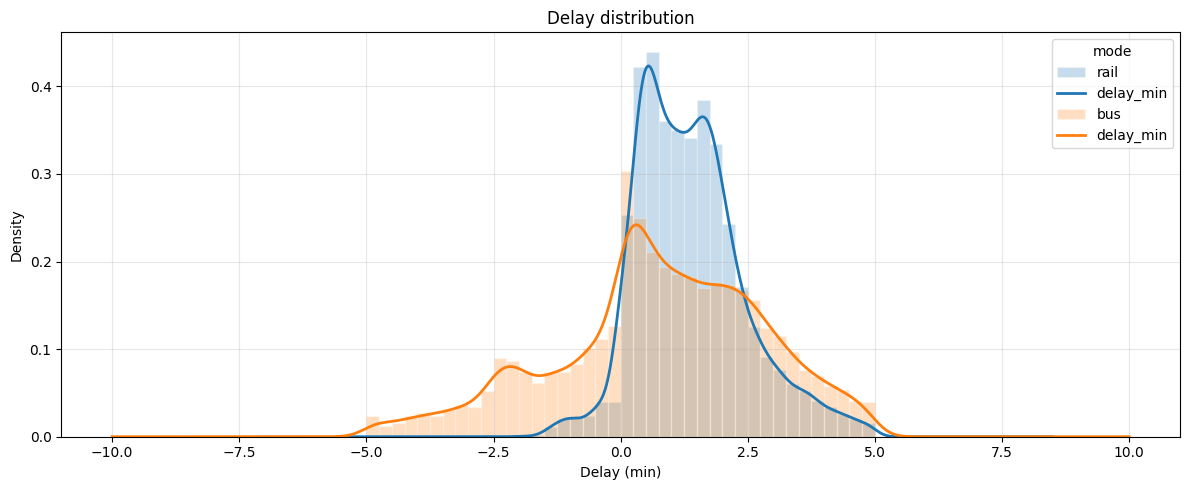

In [37]:
import matplotlib.pyplot as plt

# Delay distribution (shared bins for rail and bus)
plot_df = gtfs.loc[gtfs["delay_sec"].notna(), ["mode_group", "delay_sec"]].copy()
plot_df["delay_min"] = plot_df["delay_sec"] / 60.0
plot_df = plot_df[plot_df["mode_group"].isin(["rail", "bus"])].copy()
plot_df = plot_df[plot_df["delay_min"].between(-5, 5, inclusive="both")].copy() 

# Common bins across both modes (based on filtered data)
bin_width = 0.25  # minutes
x_min = np.floor(plot_df["delay_min"].min() / bin_width) * bin_width
x_max = np.ceil(plot_df["delay_min"].max() / bin_width) * bin_width
bins = np.arange(x_min, x_max + bin_width, bin_width)

fig, ax = plt.subplots(figsize=(12, 5))
palette = {"rail": "#1f77b4", "bus": "#ff7f0e"}

for mode in ["rail", "bus"]:
   s = plot_df.loc[plot_df["mode_group"] == mode, "delay_min"]
   ax.hist(
      s,
      bins=bins,
      density=True,
      alpha=0.25,
      color=palette[mode],
      label=mode,
      edgecolor="white",
   )
   if len(s) > 1:
      s.plot(kind="kde", ax=ax, color=palette[mode], linewidth=2)

ax.set_title("Delay distribution")
ax.set_xlabel("Delay (min)")
ax.set_ylabel("Density")
ax.legend(title="mode")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# Headways: per mode, per direction, and per hour of day
import matplotlib.pyplot as plt

df_headways = gtfs.copy()

# arrival_time in this dataset is unix seconds
df_headways["arrival_time_dt"] = pd.to_datetime(df_headways["arrival_time"], unit="s", errors="coerce")
df_headways = df_headways.dropna(subset=["arrival_time_dt", "trip_id", "mode_group", "direction_id"]).copy()

group_cols = ["mode_group", "direction_id", "observation_date", "stop_name", "hour"]
df_headways = df_headways.sort_values(group_cols + ["arrival_time_dt"])
df_headways["headway_sec"] = df_headways.groupby(group_cols, dropna=False)["arrival_time_dt"].diff().dt.total_seconds()

# Keep realistic headways (0-60 minutes)
headways = df_headways[
    df_headways["headway_sec"].notna()
    & (df_headways["headway_sec"] > 0)
    & (df_headways["headway_sec"] <= 3600)
][group_cols + ["headway_sec"]].copy()
headways["headways_min"] = headways["headway_sec"] / 60.0

headways_per_mode = (
    headways.groupby("mode_group", dropna=False)
    .agg(
        observations=("headways_min", "size"),
        mean_headways_min=("headways_min", "mean"),
        median_headways_min=("headways_min", "median"),
        p90_headways_min=("headways_min", lambda s: s.quantile(0.90)),
    )
    .reset_index()
    .sort_values("mode_group")
)

headways_per_direction = (
    headways.groupby(["mode_group", "direction_id"], dropna=False)
    .agg(
        observations=("headways_min", "size"),
        mean_headways_min=("headways_min", "mean"),
        median_headways_min=("headways_min", "median"),
        p90_headways_min=("headways_min", lambda s: s.quantile(0.90)),
    )
    .reset_index()
    .sort_values(["mode_group", "direction_id"])
)

headways_per_hour = (
    headways.groupby(["mode_group", "hour"], dropna=False)
    .agg(
        observations=("headways_min", "size"),
        mean_headways_min=("headways_min", "mean"),
        median_headways_min=("headways_min", "median"),
        p90_headways_min=("headways_min", lambda s: s.quantile(0.90)),
    )
    .reset_index()
    .sort_values(["mode_group", "hour"])
)

headways_by_direction = (
    headways.groupby(["mode_group", "direction_id", "hour"], dropna=False)
    .agg(
        observations=("headways_min", "size"),
        mean_headways_min=("headways_min", "mean"),
        median_headways_min=("headways_min", "median"),
    )
    .reset_index()
    .sort_values(["mode_group", "direction_id", "hour"])
)

# Build readable direction names from dominant first/last corridor sections when possible
direction_name_map = {}
if "stop_to_section" in globals():
    route_source = df_headways.copy()
    route_source["route_section"] = route_source["stop_name"].map(stop_to_section)
    route_source = route_source.dropna(subset=["route_section", "arrival_time_dt"])
    route_pairs = (
        route_source.sort_values("arrival_time_dt")
        .groupby(["direction_id", "trip_id", "observation_date"], as_index=False)
        .agg(
            first_section=("route_section", "first"),
            last_section=("route_section", "last"),
        )
    )

    pair_counts = (
        route_pairs.groupby(["direction_id", "first_section", "last_section"], dropna=False)
        .size()
        .reset_index(name="trips")
        .sort_values(["direction_id", "trips"], ascending=[True, False])
    )

    for direction_value, grp in pair_counts.groupby("direction_id"):
        top = grp.iloc[0]
        direction_name_map[int(direction_value)] = f"{top['first_section']} -> {top['last_section']}"

for direction_value in sorted(headways_by_direction["direction_id"].dropna().unique()):
    direction_name_map.setdefault(int(direction_value), f"Direction {int(direction_value)}")

headways_per_direction["direction"] = headways_per_direction["direction_id"].map(lambda x: direction_name_map.get(int(x), f"Direction {int(x)}"))
headways_by_direction["direction"] = headways_by_direction["direction_id"].map(lambda x: direction_name_map.get(int(x), f"Direction {int(x)}"))

for table in [headways_per_mode, headways_per_direction, headways_per_hour, headways_by_direction]:
    for c in ["mean_headways_min", "median_headways_min"]:
        if c in table.columns:
            table[c] = table[c].round(2)
    if "p90_headways_min" in table.columns:
        table["p90_headways_min"] = table["p90_headways_min"].round(2)

print("Headway time by mode (minutes):")
display(headways_per_mode)

print("\nHeadway time by mode and direction (minutes):")
display(headways_per_direction[["mode_group", "direction", "observations", "mean_headways_min", "median_headways_min", "p90_headways_min"]])

print("\nHourly headway time by mode (minutes):")
display(headways_per_hour)

print("\nHourly headway time by mode and direction (minutes):")
display(headways_by_direction[["mode_group", "direction", "hour", "observations", "mean_headways_min", "median_headways_min"]])


Headway time by mode (minutes):


,mode_group,observations,mean_headways_min,median_headways_min,p90_headways_min
0,bus,24613,7.05,4.82,15.98
1,rail,8215,12.66,11.77,20.56



Headway time by mode and direction (minutes):


,mode_group,direction,observations,mean_headways_min,median_headways_min,p90_headways_min
0,bus,Direction 0,13044,6.93,4.88,15.66
1,bus,Direction 1,11569,7.19,4.77,16.19
2,rail,Direction 0,4128,12.65,12.93,20.60
3,rail,Direction 1,4087,12.67,11.28,20.52



Hourly headway time by mode (minutes):


,mode_group,hour,observations,mean_headways_min,median_headways_min,p90_headways_min
0,bus,0,348,16.06,12.45,31.12
1,bus,1,58,42.14,43.50,54.67
2,bus,2,41,30.74,35.62,48.75
3,bus,3,37,21.26,18.40,42.29
4,bus,4,54,27.17,27.87,31.02
5,bus,5,413,7.36,4.37,16.29
6,bus,6,1311,6.05,3.97,14.62
7,bus,7,2130,4.48,2.20,11.55
8,bus,8,2120,4.60,2.05,13.34
9,bus,9,1609,5.94,3.92,14.17



Hourly headway time by mode and direction (minutes):


,mode_group,direction,hour,observations,mean_headways_min,median_headways_min
0,bus,Direction 0,0,166,20.44,14.28
1,bus,Direction 0,1,31,51.12,51.55
2,bus,Direction 0,3,16,29.89,29.61
3,bus,Direction 0,4,42,26.11,27.09
4,bus,Direction 0,5,377,7.16,4.37
...,...,...,...,...,...,...
84,rail,Direction 1,19,260,10.58,10.65
85,rail,Direction 1,20,196,14.33,12.72
86,rail,Direction 1,21,92,24.54,29.61
87,rail,Direction 1,22,60,30.06,30.06


In [18]:
# Define route sections with their stop names
ROUTE_SECTIONS = [
    ("Arninge", ["Arninge station", "Arninge"]),
    ("Roslags Näsby", ["Roslags Näsby", "Roslags Näsby trafikplats"]),
    ("Mörby", ["Mörby", "Mörby centrum", "Mörby centrum/E18"]),
    ("Universitetet", ["Universitetet", "Universitetet södra"]),
    ("Tekniska/Östra", ["Tekniska högskolan", "Stockholms östra"]),
]

# Create a mapping of stop names to sections
stop_to_section = {}
for section_name, stops in ROUTE_SECTIONS:
    for stop in stops:
        stop_to_section[stop] = section_name

# Use raw_gtfs for complete travel data (not filtered by site)
travel_data = raw_gtfs[
    (raw_gtfs["observation_date"].isin(shared_dates))
].copy()

travel_data["route_section"] = travel_data["stop_name"].map(stop_to_section)

# Convert Unix timestamps to datetime (they are in seconds)
travel_data["arrival_time_dt"] = pd.to_datetime(travel_data["arrival_time"], unit="s", errors="coerce")
travel_data["departure_time_dt"] = pd.to_datetime(travel_data["departure_time"], unit="s", errors="coerce")

# For each trip, find transition times between sections
travel_segments = []

for trip_id in travel_data["trip_id"].unique():
    trip_data = travel_data[travel_data["trip_id"] == trip_id].copy()
    
    # Sort by arrival time to get the sequence of stops
    trip_data = trip_data.sort_values("arrival_time_dt").reset_index(drop=True)
    
    # Filter to stops with valid sections
    trip_data = trip_data[trip_data["route_section"].notna()].reset_index(drop=True)
    
    if len(trip_data) < 2:
        continue
    
    # Track transitions between sections
    for idx in range(len(trip_data) - 1):
        current_row = trip_data.iloc[idx]
        next_row = trip_data.iloc[idx + 1]
        
        current_section = current_row["route_section"]
        next_section = next_row["route_section"]
        
        # Only record when we transition to a different section
        if (current_section != next_section and 
            pd.notna(current_row["arrival_time_dt"]) and 
            pd.notna(next_row["arrival_time_dt"])):
            
            # Calculate travel time from current arrival to next arrival
            travel_time_delta = next_row["arrival_time_dt"] - current_row["arrival_time_dt"]
            travel_time_sec = travel_time_delta.total_seconds()
            
            # Only record if reasonable (between 1 and 1800 seconds, i.e., ~30 mins)
            if 0 < travel_time_sec < 1800:
                travel_segments.append({
                    "from_section": current_section,
                    "to_section": next_section,
                    "line": current_row["line"],
                    "mode_group": current_row["mode_group"],
                    "travel_time_sec": travel_time_sec,
                    "travel_time_min": travel_time_sec / 60,
                    "trip_id": trip_id,
                    "observation_date": current_row["observation_date"],
                    "is_weekend": current_row["is_weekend"],
                })

segments_df = pd.DataFrame(travel_segments)

if len(segments_df) > 0:
    # Aggregate travel times by route segment
    travel_summary = (
        segments_df.groupby(["from_section", "to_section", "mode_group"])
        .agg(
            count=("travel_time_min", "size"),
            avg_travel_time_min=("travel_time_min", "mean"),
            median_travel_time_min=("travel_time_min", "median"),
            p25_travel_time_min=("travel_time_min", lambda s: s.quantile(0.25)),
            p75_travel_time_min=("travel_time_min", lambda s: s.quantile(0.75)),
        )
        .reset_index()
        .sort_values(["from_section", "to_section"])
    )
    
    # Round for display
    for col in ["avg_travel_time_min", "median_travel_time_min", "p25_travel_time_min", "p75_travel_time_min"]:
        travel_summary[col] = travel_summary[col].round(2)
    
    print("Travel Times Between Route Sections")
    print("=" * 100)
    display(travel_summary)
    
    # Comparison by day type
    print("\nTravel Times: Weekday vs Weekend")
    print("=" * 100)
    daytype_summary = (
        segments_df.groupby(["from_section", "to_section", "is_weekend"])
        .agg(
            count=("travel_time_min", "size"),
            avg_travel_time_min=("travel_time_min", "mean"),
            median_travel_time_min=("travel_time_min", "median"),
        )
        .reset_index()
        .sort_values(["from_section", "to_section", "is_weekend"])
    )
    
    for col in ["avg_travel_time_min", "median_travel_time_min"]:
        daytype_summary[col] = daytype_summary[col].round(2)
    
    daytype_summary["day_type"] = daytype_summary["is_weekend"].map({True: "Weekend", False: "Weekday"})
    display(daytype_summary[["from_section", "to_section", "day_type", "count", "avg_travel_time_min", "median_travel_time_min"]])
    
    print(f"\nTotal travel segments analyzed: {len(segments_df)}")
    
else:
    print("No travel segments found.")

Travel Times Between Route Sections


,from_section,to_section,mode_group,count,avg_travel_time_min,median_travel_time_min,p25_travel_time_min,p75_travel_time_min
0,Arninge,Roslags Näsby,bus,2456,6.49,5.38,4.98,6.97
1,Arninge,Roslags Näsby,rail,1084,10.54,10.47,10.20,10.75
2,Mörby,Roslags Näsby,bus,353,6.07,6.02,5.68,6.35
3,Mörby,Roslags Näsby,rail,1091,8.21,9.10,6.32,9.62
4,Mörby,Tekniska/Östra,bus,684,12.59,12.42,11.45,13.52
5,Mörby,Universitetet,bus,907,8.17,8.08,7.39,8.75
6,Mörby,Universitetet,rail,1084,3.56,3.52,3.43,3.60
7,Roslags Näsby,Arninge,bus,2598,6.39,5.60,5.18,6.12
8,Roslags Näsby,Arninge,rail,1090,10.41,10.32,10.05,10.63
9,Roslags Näsby,Mörby,bus,2566,5.23,4.97,4.62,5.48



Travel Times: Weekday vs Weekend


,from_section,to_section,day_type,count,avg_travel_time_min,median_travel_time_min
0,Arninge,Roslags Näsby,Weekday,2950,7.67,6.48
1,Arninge,Roslags Näsby,Weekend,590,8.00,9.82
2,Mörby,Roslags Näsby,Weekday,1129,7.69,6.92
3,Mörby,Roslags Näsby,Weekend,315,7.69,8.13
4,Mörby,Tekniska/Östra,Weekday,637,12.66,12.50
5,Mörby,Tekniska/Östra,Weekend,47,11.75,11.57
6,Mörby,Universitetet,Weekday,1555,5.77,3.87
7,Mörby,Universitetet,Weekend,436,5.29,3.62
8,Roslags Näsby,Arninge,Weekday,2892,7.64,6.07
9,Roslags Näsby,Arninge,Weekend,796,7.37,5.74



Total travel segments analyzed: 21713


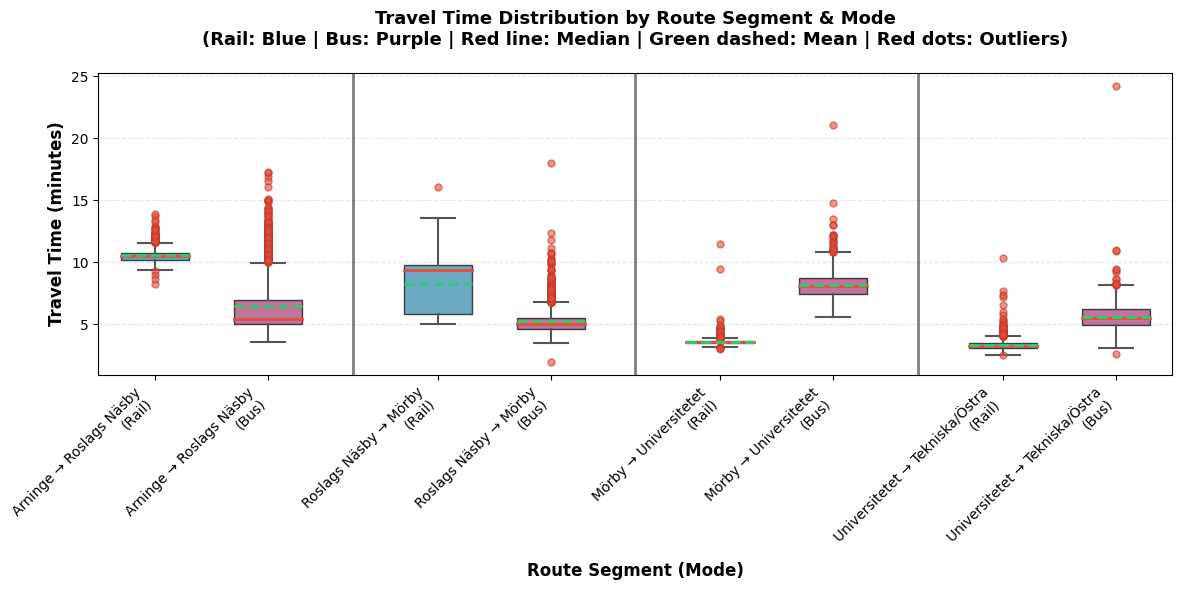


TRAVEL TIME SUMMARY BY SEGMENT & MODE (minutes)
Segment                                            Mode   Count    Mean       Median     Std Dev    Min        Max       
------------------------------------------------------------------------------------------------------------------------
Arninge → Roslags Näsby                            Rail   1084     10.54      10.47      0.55       8.20       13.87     
Arninge → Roslags Näsby                            Bus    2456     6.49       5.38       2.39       3.58       17.23     
Roslags Näsby → Mörby                              Rail   1084     8.20       9.38       1.96       5.00       16.05     
Roslags Näsby → Mörby                              Bus    2566     5.23       4.97       1.04       1.97       18.02     
Mörby → Universitetet                              Rail   1084     3.56       3.52       0.37       3.00       11.45     
Mörby → Universitetet                              Bus    907      8.17       8.08       1.23     

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Define the correct order of sections
section_order = [
    "Arninge",
    "Roslags Näsby",
    "Mörby",
    "Universitetet",
    "Tekniska/Östra"
]

# Prepare data for box plots - separate by mode for each segment
segment_data_by_mode = []  # Will contain data for plotting
x_positions = []
x_labels = []
colors_list = []
mode_list = []

x_pos = 1
for i in range(len(section_order) - 1):
    from_sec = section_order[i]
    to_sec = section_order[i + 1]
    segment_name = f"{from_sec} → {to_sec}"
    
    # Get rail data
    rail_times = segments_df[
        (segments_df["from_section"] == from_sec) & 
        (segments_df["to_section"] == to_sec) &
        (segments_df["mode_group"] == "rail")
    ]["travel_time_min"].values
    
    # Get bus data 
    bus_times = segments_df[
        (segments_df["from_section"] == from_sec) & 
        (segments_df["to_section"] == to_sec) &
        (segments_df["mode_group"] == "bus")
    ]["travel_time_min"].values
    
    if len(rail_times) > 0:
        segment_data_by_mode.append(rail_times)
        x_positions.append(x_pos)
        x_labels.append(f"{segment_name}\n(Rail)")
        colors_list.append('#2E86AB')  # Blue for rail
        mode_list.append(('rail', segment_name))
        x_pos += 1
    
    if len(bus_times) > 0:
        segment_data_by_mode.append(bus_times)
        x_positions.append(x_pos)
        x_labels.append(f"{segment_name}\n(Bus)")
        colors_list.append('#A23B72')  # Purple for bus
        mode_list.append(('bus', segment_name))
        x_pos += 1
    
    x_pos += 0.5  # Small gap between segment groups

# Create the box plot
fig, ax = plt.subplots(figsize=(12, 6))

bp = ax.boxplot(
    segment_data_by_mode,
    positions=x_positions,
    labels=x_labels,
    patch_artist=True,
    showmeans=True,
    meanline=True,
    widths=0.6
)

# Customize colors for boxes by mode
for patch, color in zip(bp['boxes'], colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Customize median lines
for median in bp['medians']:
    median.set_color('#e74c3c')
    median.set_linewidth(2)

# Customize mean lines
for mean in bp['means']:
    mean.set_color('#2ecc71')
    mean.set_linewidth(2)
    mean.set_linestyle('--')

# Customize whiskers and caps
for whisker in bp['whiskers']:
    whisker.set_linewidth(1.5)
    whisker.set_color('#555555')

for cap in bp['caps']:
    cap.set_linewidth(1.5)
    cap.set_color('#555555')

# Customize outliers
for flier in bp['fliers']:
    flier.set_marker('o')
    flier.set_markerfacecolor('#e74c3c')
    flier.set_markeredgecolor('#c0392b')
    flier.set_markersize(5)
    flier.set_alpha(0.6)

ax.set_ylabel('Travel Time (minutes)', fontsize=12, fontweight='bold')
ax.set_xlabel('Route Segment (Mode)', fontsize=12, fontweight='bold')
ax.set_title('Travel Time Distribution by Route Segment & Mode\n(Rail: Blue | Bus: Purple | Red line: Median | Green dashed: Mean | Red dots: Outliers)', 
             fontsize=13, fontweight='bold', pad=20)

ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add vertical separators between segments
for i in range(len(section_order) - 1):
    if i < len(section_order) - 2:
        # Find position of last box in this segment group
        current_segment_positions = [pos for pos, (mode, seg) in zip(x_positions, mode_list) if seg == f"{section_order[i]} → {section_order[i+1]}"]
        if current_segment_positions:
            separator_x = max(current_segment_positions) + 0.75
            ax.axvline(x=separator_x, color='black', linestyle='-', alpha=0.5, linewidth=2)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print detailed summary statistics
print("\n" + "="*120)
print("TRAVEL TIME SUMMARY BY SEGMENT & MODE (minutes)")
print("="*120)
print(f"{'Segment':<50} {'Mode':<6} {'Count':<8} {'Mean':<10} {'Median':<10} {'Std Dev':<10} {'Min':<10} {'Max':<10}")
print("-"*120)

for i in range(len(section_order) - 1):
    from_sec = section_order[i]
    to_sec = section_order[i + 1]
    segment_name = f"{from_sec} → {to_sec}"
    
    for mode in ['rail', 'bus']:
        segment_data = segments_df[
            (segments_df["from_section"] == from_sec) & 
            (segments_df["to_section"] == to_sec) &
            (segments_df["mode_group"] == mode)
        ]["travel_time_min"]
        
        if len(segment_data) > 0:
            mode_label = 'Rail' if mode == 'rail' else 'Bus'
            print(f"{segment_name:<50} {mode_label:<6} {len(segment_data):<8} {segment_data.mean():<10.2f} {segment_data.median():<10.2f} {segment_data.std():<10.2f} {segment_data.min():<10.2f} {segment_data.max():<10.2f}")

print("="*120)

Computed journey_df rows: 9054

Sample counts by mode:
{'bus': 6239, 'rail': 2815}
Removed 58 extreme bus rows (cap=65.7 min)
Removed 1 extreme rail rows (cap=59.5 min)
Filtered journey_df rows: 8995 (removed total 59 rows)


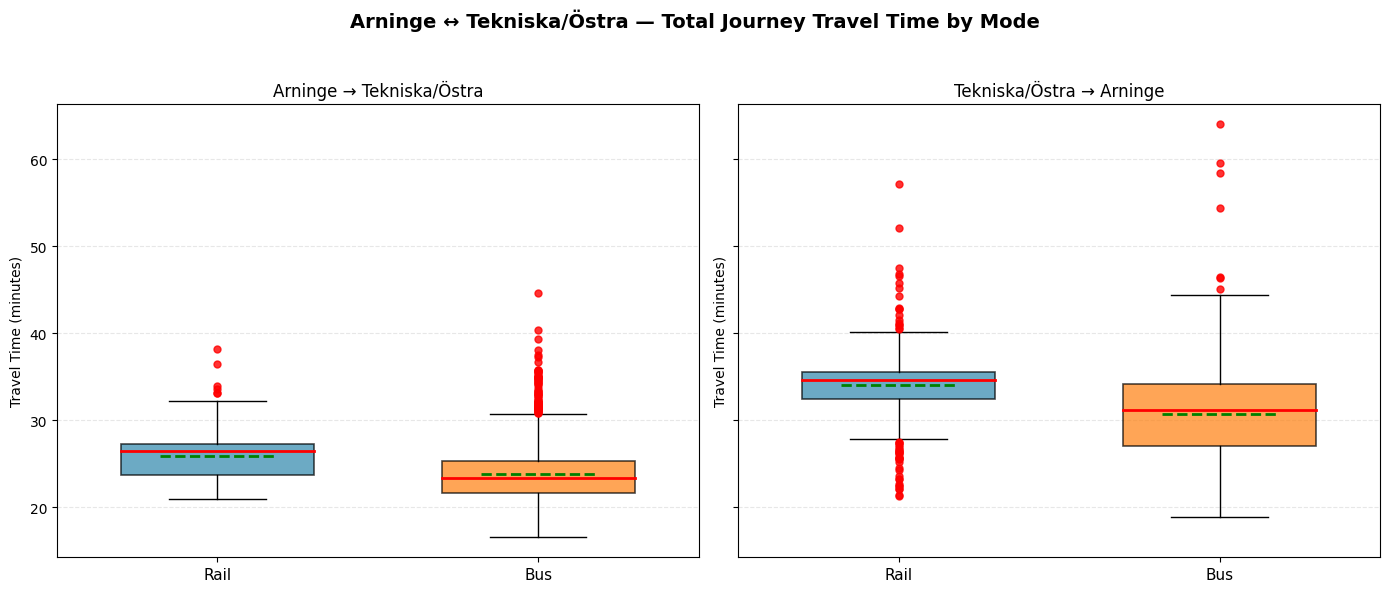

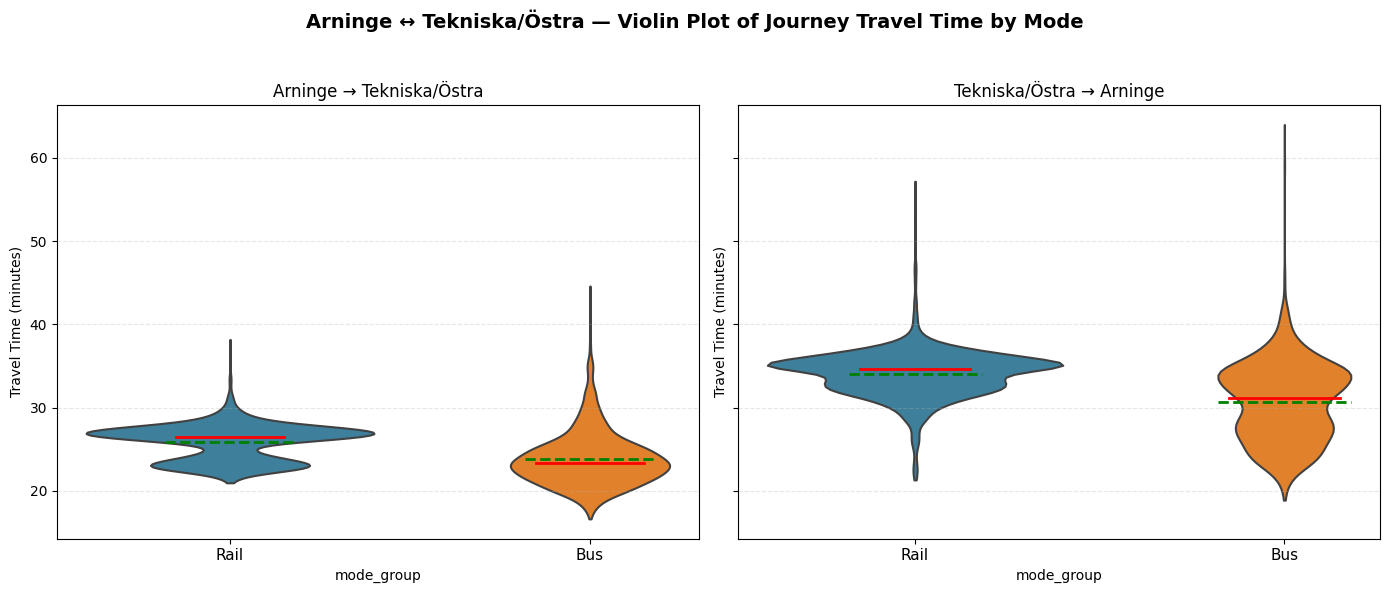

In [20]:
# Minimal: compute journey travel times per trip instance (trip_id + observation_date)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

if 'raw_gtfs' not in globals():
    raise RuntimeError('raw_gtfs not found; run the GTFS load cells first')
if 'stop_to_section' not in globals():
    raise RuntimeError('stop_to_section mapping not found; run the route section cell')

raw = raw_gtfs.copy()
raw['arrival_time_dt'] = pd.to_datetime(raw['arrival_time'], unit='s', errors='coerce')
raw['route_section'] = raw['stop_name'].map(stop_to_section)

# keep only rows with mapped section and valid datetime
mask = raw['route_section'].notna() & raw['arrival_time_dt'].notna()
raw_mapped = raw[mask].copy()

# group by trip instance and take first/last arrival within same trip+date
grouped = (
    raw_mapped.sort_values('arrival_time_dt')
    .groupby(['trip_id','observation_date'], as_index=False)
    .agg(
        first_time=('arrival_time_dt','first'),
        last_time=('arrival_time_dt','last'),
        first_section=('route_section','first'),
        last_section=('route_section','last'),
        line=('line','first'),
        mode_group=('mode_group','first'),
        direction_id=('direction_id','first')
    )
)

grouped['travel_min'] = (grouped['last_time'] - grouped['first_time']).dt.total_seconds() / 60.0

# filter to reasonable journeys
journeys = grouped[(grouped['travel_min'] > 0) & (grouped['travel_min'] < 10000)].copy()  # keep everything (but avoid infinities)
# make name consistent with notebook
journey_df = journeys.copy()
journey_df['mode_group'] = journey_df['mode_group'].astype(str).str.lower()

print('Computed journey_df rows:', len(journey_df))
print('\nSample counts by mode:')
print(journey_df['mode_group'].value_counts(dropna=False).to_dict())

# Define corridor masks for both directions
mask_a_to_b = (journey_df['first_section']=='Arninge') & (journey_df['last_section'].str.contains('Tekniska', na=False))
mask_b_to_a = (journey_df['first_section'].str.contains('Tekniska', na=False)) & (journey_df['last_section']=='Arninge')

# ---- Remove huge outliers (per-mode cap using Q3 + 3*IQR) ----
caps = {}
for mode, grp in journey_df.groupby('mode_group'):
    Q1 = grp['travel_min'].quantile(0.25)
    Q3 = grp['travel_min'].quantile(0.75)
    IQR = Q3 - Q1
    cap = Q3 + 3 * IQR
    caps[mode] = cap

journey_df_filtered = journey_df.copy()
removed_rows = 0
for mode, cap in caps.items():
    before = len(journey_df_filtered)
    journey_df_filtered = journey_df_filtered[~((journey_df_filtered['mode_group']==mode) & (journey_df_filtered['travel_min']>cap))]
    after = len(journey_df_filtered)
    removed = before - after
    removed_rows += removed
    print(f"Removed {removed} extreme {mode} rows (cap={cap:.1f} min)")

print('Filtered journey_df rows:', len(journey_df_filtered), '(removed total', removed_rows, 'rows)')

# Use filtered dataframe for plotting
journey_df_plot = journey_df_filtered

# Prepare two-panel boxplot for both directions
fig, axes = plt.subplots(1, 2, figsize=(14,6), sharey=True)
fig.suptitle('Arninge ↔ Tekniska/Östra — Total Journey Travel Time by Mode', fontsize=14, fontweight='bold')

directions = [
    ('Arninge → Tekniska/Östra', mask_a_to_b),
    ('Tekniska/Östra → Arninge', mask_b_to_a)
]

palette = {'rail':'#2E86AB','bus':'#ff7f0e'}
medianprops = dict(color='red', linewidth=2)
# mean will be plotted as a green dashed horizontal line
flierprops = dict(marker='o', markerfacecolor='red', markeredgecolor='red', markersize=5, alpha=0.8)
boxprops = dict(linewidth=1.2)

for ax, (title, m) in zip(axes, directions):
    sub = journey_df_plot.loc[m].copy()
    if sub.empty:
        ax.text(0.5,0.5,'No data', ha='center', va='center')
        ax.set_title(title)
        continue

    rail_times = sub.loc[sub['mode_group']=='rail','travel_min'].values
    bus_times = sub.loc[sub['mode_group']=='bus','travel_min'].values
    bp_data = []
    labels = []
    colors = []
    if len(rail_times)>0:
        bp_data.append(rail_times)
        labels.append('Rail')
        colors.append(palette['rail'])
    if len(bus_times)>0:
        bp_data.append(bus_times)
        labels.append('Bus')
        colors.append(palette['bus'])

    bp = ax.boxplot(bp_data, labels=labels, patch_artist=True, showmeans=False,
                    medianprops=medianprops, flierprops=flierprops, widths=0.6, boxprops=boxprops)

    # set box face colors
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)



    # draw mean as green dashed horizontal small line per group
    for i, data in enumerate(bp_data):
        if len(data) == 0:
            continue
        mean_val = np.mean(data)
        ax.plot([i+1-0.18, i+1+0.18], [mean_val, mean_val], color='green', linestyle='--', linewidth=2)

    # annotate counts
    counts = [len(arr) for arr in bp_data]
    xticks = [f"{lab}" for lab,cnt in zip(labels, counts)]
    ax.set_xticklabels(xticks, fontsize=11)

    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Travel Time (minutes)')
    ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

# ---- Violin plots (one row, two columns) ----
fig, axes = plt.subplots(1,2,figsize=(14,6), sharey=True)
fig.suptitle('Arninge ↔ Tekniska/Östra — Violin Plot of Journey Travel Time by Mode', fontsize=14, fontweight='bold')

for ax, (title, m) in zip(axes, directions):
    sub = journey_df_plot.loc[m].copy()
    if sub.empty:
        ax.text(0.5,0.5,'No data', ha='center', va='center')
        ax.set_title(title)
        continue

    plot_df = sub[sub['mode_group'].isin(['rail','bus'])]
    sns.violinplot(x='mode_group', y='travel_min', data=plot_df, order=['rail','bus'], palette=palette, ax=ax, inner=None, cut=0)

    # overlay median (red line) and mean (green dashed line)
    stats = plot_df.groupby('mode_group')['travel_min'].agg(['mean','median','count'])
    for i, mode in enumerate(['rail','bus']):
        if mode in stats.index:
            mean = stats.loc[mode,'mean']
            median = stats.loc[mode,'median']
            ax.plot([i-0.18, i+0.18], [mean, mean], color='green', linestyle='--', linewidth=2, zorder=10)
            ax.plot([i-0.15, i+0.15], [median, median], color='red', linewidth=2, zorder=9)

    # annotate counts in tick labels
    counts = stats['count'].reindex(['rail','bus']).fillna(0).astype(int).tolist()
    xticks = [f"Rail", f"Bus"]
    ax.set_xticklabels(xticks, fontsize=11)
    ax.set_title(title)
    ax.set_ylabel('Travel Time (minutes)')
    ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


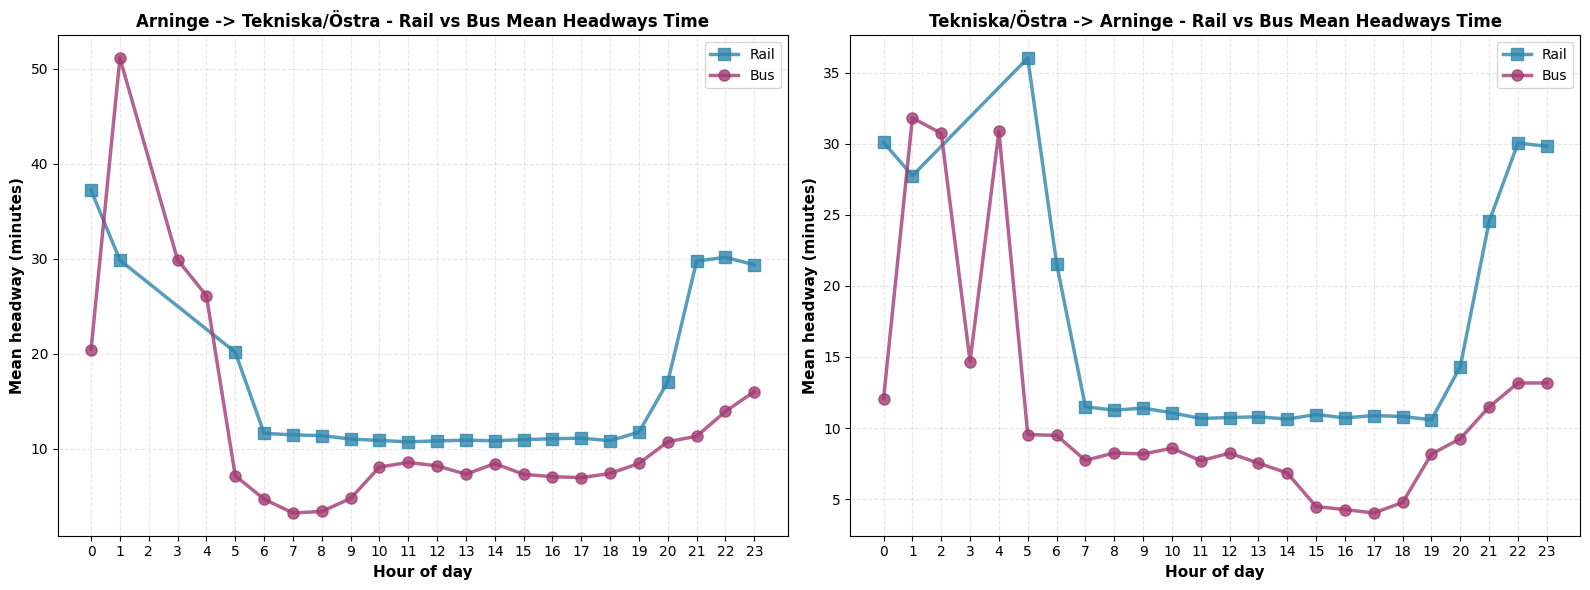


RAIL VS BUS HEADWAY TIME COMPARISON BY ROUTE

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Arninge -> Tekniska/Östra
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
      Bus (min)  Rail (min)  Difference (Bus-Rail)  Ratio (Bus/Rail)
Hour                                                                
0         20.44       37.22                 -16.78              0.55
1         51.12       29.85                  21.27              1.71
3         29.89         NaN                    NaN               NaN
4         26.11         NaN                    NaN               NaN
5          7.16       20.16                 -13.00              0.36
6          4.70       11.62                  -6.92              0.40
7          3.24       11.46                  -8.22              0.28
8          3.40       11.38                  -7.98              

In [21]:
# Rail vs Bus headwaysing time comparison by direction
import pandas as pd
import matplotlib.pyplot as plt

# Using headways_by_direction from previous cell
rail_bus_by_direction = headways_by_direction.copy()

# Create side-by-side plots for each route
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

directions = sorted(rail_bus_by_direction['direction_id'].unique())

direction_labels = {
            0: "Arninge -> Tekniska/Östra",
            1: "Tekniska/Östra -> Arninge",
        }

for dir_idx, direction in enumerate(directions):
    ax = axes[dir_idx]
    
    # Get data for this direction
    dir_data = rail_bus_by_direction[rail_bus_by_direction['direction_id'] == direction]
    route_label = direction_labels.get(int(direction), f'Direction {int(direction)}')
    
    # Plot rail and bus
    for mode in ['rail', 'bus']:
        mode_data = dir_data[dir_data['mode_group'] == mode].sort_values('hour')
        color = '#2E86AB' if mode == 'rail' else '#A23B72'
        marker = 's' if mode == 'rail' else 'o'
        ax.plot(mode_data['hour'], mode_data['mean_headways_min'], 
               marker=marker, linewidth=2.5, markersize=8, 
               label=f'{mode.capitalize()}', color=color, alpha=0.8)
    
    ax.set_xticks(range(0, 24))
    ax.set_xlabel('Hour of day', fontsize=11, fontweight='bold')
    ax.set_ylabel('Mean headway (minutes)', fontsize=11, fontweight='bold')
    ax.set_title(f'{route_label} - Rail vs Bus Mean Headways Time', 
                fontsize=12, fontweight='bold')
    ax.legend(fontsize=10, loc='best')
    ax.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Detailed comparison tables
print("\n" + "="*120)
print("RAIL VS BUS HEADWAY TIME COMPARISON BY ROUTE")
print("="*120)
        
for direction in sorted(directions):
    route_label = direction_labels.get(int(direction), f'Direction {int(direction)}')
    print(f"\n{'─'*120}")
    print(route_label)
    print(f"{'─'*120}")
    
    dir_data = rail_bus_by_direction[rail_bus_by_direction['direction_id'] == direction].sort_values('hour')
    
    # Pivot to compare rail and bus side by side
    comparison = dir_data.pivot_table(
        index='hour',
        columns='mode_group',
        values='mean_headways_min',
        aggfunc='first'
    )
    
    if comparison is not None and len(comparison) > 0:
        comparison['diff_bus_minus_rail'] = comparison.get('bus', 0) - comparison.get('rail', 0)
        comparison['ratio_bus_rail'] = (comparison.get('bus', 0) / comparison.get('rail', 0)).round(2)
        
        # Format for display
        comparison_display = comparison.round(2)
        comparison_display.index.name = 'Hour'
        comparison_display.columns = ['Bus (min)', 'Rail (min)', 'Difference (Bus-Rail)', 'Ratio (Bus/Rail)']
        
        print(comparison_display.to_string())
        
        # Summary statistics
        print(f"\n  Overall Average Headway:")
        print(f"    - Rail:  {comparison.get('rail', 0).mean():.2f} minutes")
        print(f"    - Bus:   {comparison.get('bus', 0).mean():.2f} minutes")
        print(f"    - Ratio: Bus is {(comparison.get('bus', 0).mean() / comparison.get('rail', 0).mean()):.2f}x the frequency of rail")

print("\n" + "="*120)

In [34]:
# Average headways by peak window (AM / PM / off-peak)
if 'headways' not in globals():
    raise RuntimeError('headways DataFrame not found; run the headways cell above')

def _peak_from_hour(h):
    try:
        h = int(h)
    except Exception:
        return 'off_peak'
    if 7 <= h <= 8:
        return 'AM_peak_07_09'
    if 16 <= h <= 17:
        return 'PM_peak_16_18'
    return 'off_peak'

# Work on a copy to avoid side-effects
headways = headways.copy()
headways['peak_window'] = headways['hour'].map(_peak_from_hour)

peak_headways = (
    headways.groupby(['mode_group', 'peak_window'], dropna=False)
    .agg(
        observations=('headways_min', 'size'),
        mean_headways_min=('headways_min', 'mean'),
        median_headways_min=('headways_min', 'median'),
    )
    .reset_index()
)
for c in ['mean_headways_min', 'median_headways_min']:
    peak_headways[c] = peak_headways[c].round(2)

print('Average headways by mode and peak window (minutes):')
display(peak_headways.sort_values(['mode_group','peak_window']))

# Pivot for easier comparison
pivot = peak_headways.pivot(index='mode_group', columns='peak_window', values='mean_headways_min')
print('\nMean headway (min) pivot:')
display(pivot.round(2))

# Optional: average per direction as well (if available)
if 'direction_id' in headways.columns:
    peak_headways_dir = (
        headways.groupby(['mode_group','direction_id','peak_window'], dropna=False)
        .agg(mean_headways_min=('headways_min','mean'), observations=('headways_min','size'))
        .reset_index()
    )
    peak_headways_dir['mean_headways_min'] = peak_headways_dir['mean_headways_min'].round(2)
    print('\nAverage headways by mode, direction and peak window:')
    display(peak_headways_dir.sort_values(['mode_group','direction_id','peak_window']))

Average headways by mode and peak window (minutes):


,mode_group,peak_window,observations,mean_headways_min,median_headways_min
0,bus,AM_peak_07_09,4250,4.54,2.14
1,bus,PM_peak_16_18,3697,5.17,3.85
2,bus,off_peak,16666,8.11,5.93
3,rail,AM_peak_07_09,976,11.40,10.13
4,rail,PM_peak_16_18,1036,10.94,11.25
5,rail,off_peak,6203,13.15,12.15



Mean headway (min) pivot:


peak_window,AM_peak_07_09,PM_peak_16_18,off_peak
mode_group,,,
bus,4.54,5.17,8.11
rail,11.40,10.94,13.15



Average headways by mode, direction and peak window:


,mode_group,direction_id,peak_window,mean_headways_min,observations
0,bus,0,AM_peak_07_09,3.32,3137
1,bus,0,PM_peak_16_18,7.01,1330
2,bus,0,off_peak,8.23,8577
3,bus,1,AM_peak_07_09,7.97,1113
4,bus,1,PM_peak_16_18,4.14,2367
5,bus,1,off_peak,7.97,8089
6,rail,0,AM_peak_07_09,11.42,489
7,rail,0,PM_peak_16_18,11.08,516
8,rail,0,off_peak,13.11,3123
9,rail,1,AM_peak_07_09,11.38,487
